# Comparing Methods for Chemical Space Coverage: A Focus on Generative Topographic Mapping (GTM)

In this notebook, we explore how different dimensionality reduction techniques visualize molecular datasets, with a specific focus on **Generative Topographic Mapping (GTM)**. Using data from the **OpenADMET ExpansionRx Blind Challenge**, we evaluate how effectively we can project high-dimensional chemical information into an interpretable 2D latent space.

### Workflow Overview
- **Setup:** Load and preprocess the OpenADMET dataset.
- **Fingerprint Projection:** Generate RDKit count fingerprints and compare t-SNE, UMAP, and GTM.
- **Descriptor Projection:** Project physical and chemical descriptors to gain a property-based perspective.

## 1. Software Installation 
First, we'll install the necessary Python libraries

In [1]:
try:
    import google.colab
    # Only run the package installation when in Colab environment
    !uv pip install wget pandas numpy seaborn matplotlib tqdm scikit-learn opentsne umap-learn useful-rdkit-utils git+https://github.com/Laboratoire-de-Chemoinformatique/ChemographyKit
    import wget
    wget.download("https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/refs/heads/main/visualization/gtm_utils.py")
except ImportError:
    pass  # Not running in Colab

### Import the libraries we'll use for this notebook

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from openTSNE import TSNE
from umap import UMAP

import useful_rdkit_utils as uru
from gtm_utils import calc_gtm, plot_gtm_class_map

# Set visualization style
sns.set_theme(style="whitegrid", context="talk")
tqdm.pandas()

## 1. Setup and Data Ingestion

We load the training and test datasets from the OpenADMET ExpansionRx Blind Challenge. These sets are combined into a single dataframe to ensure consistent transformations across both groups.

In [3]:
BASE_URL = "hf://datasets/openadmet/openadmet-expansionrx-challenge-data/"
train_df = pd.read_csv(f"{BASE_URL}expansion_data_train.csv")
test_df = pd.read_csv(f"{BASE_URL}expansion_data_test.csv")

train_df['dataset'] = 'train'
test_df['dataset'] = 'test'

combo_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Total compounds: {len(combo_df)} (Train: {len(train_df)}, Test: {len(test_df)})")

Total compounds: 7608 (Train: 5326, Test: 2282)


## 2. Structural Space: Projecting Fingerprints 

We use **RDKit count fingerprints** to represent molecular structure. Due to their high dimensionality, we perform an initial PCA reduction to 50 dimensions (preserving the majority of variance) before applying t-SNE, UMAP, and GTM.

In [4]:
smi2fp = uru.Smi2Fp()
combo_df["fp"] = combo_df.SMILES.progress_apply(smi2fp.get_np_counts)

  0%|          | 0/7608 [00:00<?, ?it/s]

In [5]:
fp_matrix = np.stack(combo_df.fp)
fp_pca = PCA(n_components=50)
combo_df["fp_pcs"] = fp_pca.fit_transform(fp_matrix).tolist()

explained_var = np.sum(fp_pca.explained_variance_ratio_) * 100
print(f"Explained variance (50 PCs): {explained_var:.2f}%")

Explained variance (50 PCs): 69.93%


### Manifold Projections
We calculate 2D coordinates using t-SNE, UMAP, and GTM. Note that GTM also returns **responsibilities** (probabilistic node assignments) and **log-likelihoods** (model fit).

In [6]:
%%time
pcs_matrix = np.stack(combo_df.fp_pcs)

print("Calculating t-SNE...")
fp_tsne = TSNE(n_components=2, n_jobs=-1, learning_rate='auto')
combo_df[['fp_tsne_x', 'fp_tsne_y']] = fp_tsne.fit(pcs_matrix)

print("Calculating UMAP...")
fp_umap = UMAP(n_components=2, n_jobs=-1)
combo_df[['fp_umap_x', 'fp_umap_y']] = fp_umap.fit_transform(pcs_matrix)

print("Calculating GTM...")
fp_gtm_obj, fp_crd_df, fp_resps, fp_llhs = calc_gtm(pcs_matrix)
combo_df["fp_gtm_x"] = fp_crd_df.x
combo_df["fp_gtm_y"] = fp_crd_df.y
combo_df["fp_llh"] = fp_llhs

Calculating t-SNE...
Calculating UMAP...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Calculating GTM...


  0%|          | 0/300 [00:00<?, ?it/s]

CPU times: user 47.7 s, sys: 6.6 s, total: 54.3 s
Wall time: 22.1 s


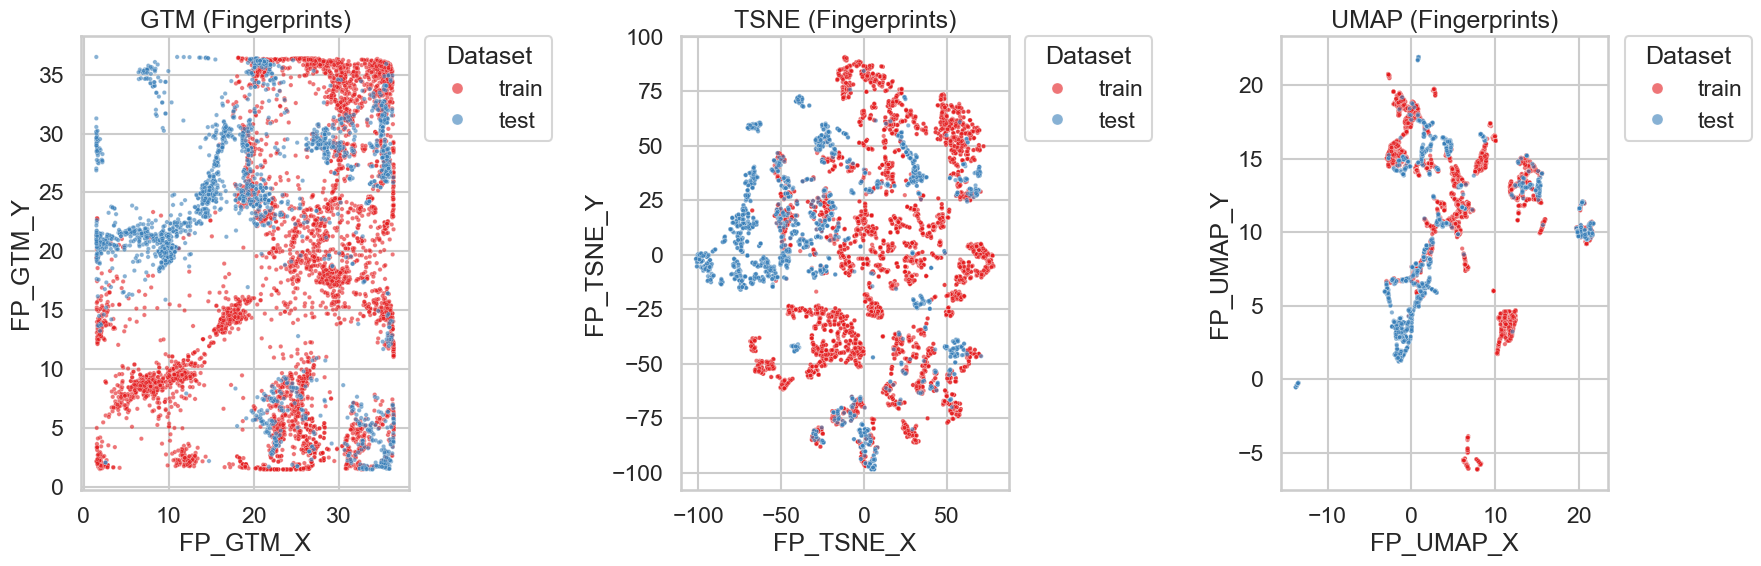

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
methods = ["gtm", "tsne", "umap"]

for i, method in enumerate(methods):
    x_col = f"fp_{method}_x"
    y_col = f"fp_{method}_y"    
    sns.scatterplot(
        x=x_col, y=y_col, 
        hue="dataset", data=combo_df, 
        ax=axes[i], s=10, alpha=0.6, palette="Set1"
    )
    axes[i].set_title(f"{method.upper()} (Fingerprints)")
    axes[i].legend(
        title="Dataset", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        borderaxespad=0.,
        markerscale=2.5            
    )
    axes[i].set_xlabel(x_col.upper())
    axes[i].set_ylabel(y_col.upper())

plt.tight_layout()
plt.show()

## 3. Property Space: Projecting RDKit Descriptors

While fingerprints capture structural connectivity, **RDKit descriptors** capture physical and chemical properties (e.g., LogP, Molecular Weight). We calculate a suite of descriptors, clean/scale them, and repeat the projections.

In [8]:
rdkit_desc = uru.RDKitDescriptors()
combo_df['desc'] = combo_df.SMILES.progress_apply(rdkit_desc.calc_smiles)

desc_matrix = np.stack(combo_df.desc)
desc_scaled, _ = uru.clean_and_scale_descriptors(desc_matrix)
print(f"Calculated and scaled {desc_scaled.shape[1]} descriptors.")

  0%|          | 0/7608 [00:00<?, ?it/s]

Calculated and scaled 217 descriptors.


In [9]:
%%time
print("Calculating t-SNE...")
tsne = TSNE(n_components=2, n_jobs=-1)
combo_df[['desc_tsne_x', 'desc_tsne_y']] = tsne.fit(desc_scaled)

print("Calculating UMAP...")
umap = UMAP(n_components=2, n_jobs=-1)
combo_df[['desc_umap_x', 'desc_umap_y']] = umap.fit_transform(desc_scaled)

print("Calculating GTM...")
desc_gtm_obj, desc_crd_df, desc_resps, desc_llhs = calc_gtm(desc_scaled)
combo_df['desc_gtm_x'] = desc_crd_df.x
combo_df['desc_gtm_y'] = desc_crd_df.y
combo_df['desc_llh'] = desc_llhs

Calculating t-SNE...
Calculating UMAP...
Calculating GTM...


  0%|          | 0/300 [00:00<?, ?it/s]

CPU times: user 3min 8s, sys: 15.4 s, total: 3min 23s
Wall time: 36 s


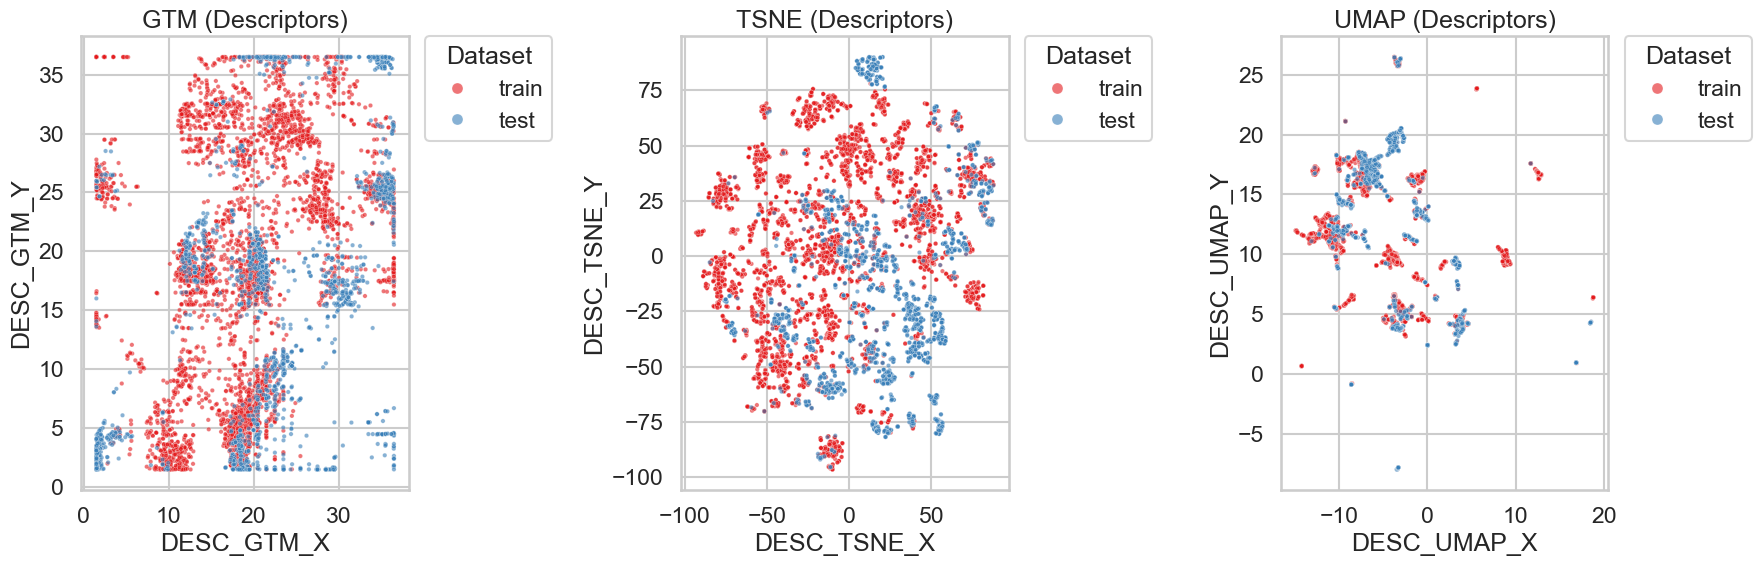

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, method in enumerate(methods):
    x_col = f"desc_{method}_x"
    y_col = f"desc_{method}_y"
    sns.scatterplot(
        x=x_col, y=y_col, 
        hue="dataset", data=combo_df, 
        ax=axes[i], s=10, alpha=0.6, palette="Set1"
    )
    axes[i].set_title(f"{method.upper()} (Descriptors)")
    axes[i].legend(
        title="Dataset", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        borderaxespad=0.,
        markerscale=2.5            
    )
    axes[i].set_xlabel(x_col.upper())
    axes[i].set_ylabel(y_col.upper())
plt.tight_layout()
plt.show()